# Supply Chain Delivery Quality Analysis
## DataCo Smart Supply Chain Dataset

### Problem Statement
More than half of all orders in the DataCo supply chain experience late delivery. 
This analysis investigates the root causes of delivery failures and order cancellations 
using a Quality Management framework.

### Dataset
- Source: DataCo Smart Supply Chain (Kaggle)
- Size: 180,519 orders | 53 features
- Period: Multi-year supply chain transactions

In [30]:
df = pd.read_csv(r'C:\Users\nourK\Downloads\DataCoSupplyChainDataset.csv\DataCoSupplyChainDataset.csv', encoding='latin-1')
print(df.shape)
print(df.columns.tolist())
df.head()

(180519, 53)
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping d

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [10]:
cols = ['Delivery Status', 'Shipping Mode', 'Order Region', 
        'Category Name', 'Order Status', 'Market', 
        'Customer Segment', 'Department Name']

for col in cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Delivery Status ---
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

--- Shipping Mode ---
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

--- Order Region ---
Order Region
Central America    28341
Western Europe     27109
South America      14935
Oceania            10148
Northern Europe     9792
Southeast Asia      9539
Southern Europe     9431
Caribbean           8318
West of USA         7993
South Asia          7731
Eastern Asia        7280
East of USA         6915
West Asia           6009
US Center           5887
South of  USA       4045
Eastern Europe      3920
West Africa         3696
North Africa        3232
East Africa         1852
Central Africa      1677
Southern Africa     1157
Canada               959
Central Asia         553
Name: count, dtype: int64

--- Category Name ---
Cat

## Data Preparation

The original dataset contains 53 columns. For this analysis, we selected 14 relevant 
columns related to delivery performance, shipping method, and order status.

A new column `shipping_gap` was created to measure the difference between actual 
and scheduled shipping days:
- Positive values = late delivery
- Zero = on time
- Negative values = early delivery

In [15]:
cols_needed = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Delivery Status',
    'Late_delivery_risk',
    'Shipping Mode',
    'Order Region',
    'Market',
    'Category Name',
    'Department Name',
    'Customer Segment',
    'Order Status',
    'order date (DateOrders)',
    'Benefit per order',
    'Sales per customer'
]

df_clean = df[cols_needed].copy()
print(df_clean.shape)

(180519, 14)


In [16]:
df_clean['order date (DateOrders)'] = pd.to_datetime(df_clean['order date (DateOrders)'])

In [17]:
df_clean['shipping_gap'] = df_clean['Days for shipping (real)'] - df_clean['Days for shipment (scheduled)']

In [18]:
df_clean.isnull().sum()

Days for shipping (real)         0
Days for shipment (scheduled)    0
Delivery Status                  0
Late_delivery_risk               0
Shipping Mode                    0
Order Region                     0
Market                           0
Category Name                    0
Department Name                  0
Customer Segment                 0
Order Status                     0
order date (DateOrders)          0
Benefit per order                0
Sales per customer               0
shipping_gap                     0
dtype: int64

## Exploratory Data Analysis

### Delivery Status Distribution
We begin by examining the overall delivery performance across all orders.

In [21]:
df_clean['Delivery Status'].value_counts(normalize=True).round(2) * 100

Delivery Status
Late delivery        55.0
Advance shipping     23.0
Shipping on time     18.0
Shipping canceled     4.0
Name: proportion, dtype: float64

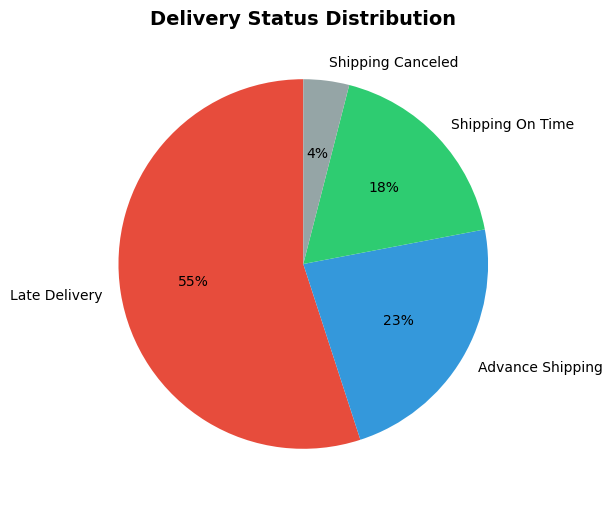

In [1]:
import matplotlib.pyplot as plt

labels = ['Late Delivery', 'Advance Shipping', 'Shipping On Time', 'Shipping Canceled']
sizes = [55, 23, 18, 4]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%', startangle=90)
plt.title('Delivery Status Distribution', fontsize=14, fontweight='bold')
plt.show()

### Finding 1: Systemic Delivery Failure
55% of all orders experience late delivery, while only 18% arrive on time.
This indicates a systemic process failure across the entire supply chain,
not an isolated regional or product issue.

In [33]:
df_clean.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False).round(2) * 100

Order Region
Central Africa     58.0
South Asia         56.0
East Africa        56.0
Western Europe     56.0
South of  USA      56.0
Eastern Europe     56.0
East of USA        56.0
Southeast Asia     56.0
Central Asia       55.0
West Asia          55.0
US Center          55.0
Central America    55.0
North Africa       55.0
Southern Europe    54.0
Eastern Asia       54.0
South America      54.0
Northern Europe    54.0
Oceania            54.0
West of USA        54.0
Southern Africa    53.0
Caribbean          53.0
West Africa        53.0
Canada             49.0
Name: Late_delivery_risk, dtype: float64

### Shipping Mode Performance
We examine whether the shipping method affects delivery performance.

In [23]:
df_clean.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False).round(2) * 100

Shipping Mode
First Class       95.0
Second Class      77.0
Same Day          46.0
Standard Class    38.0
Name: Late_delivery_risk, dtype: float64

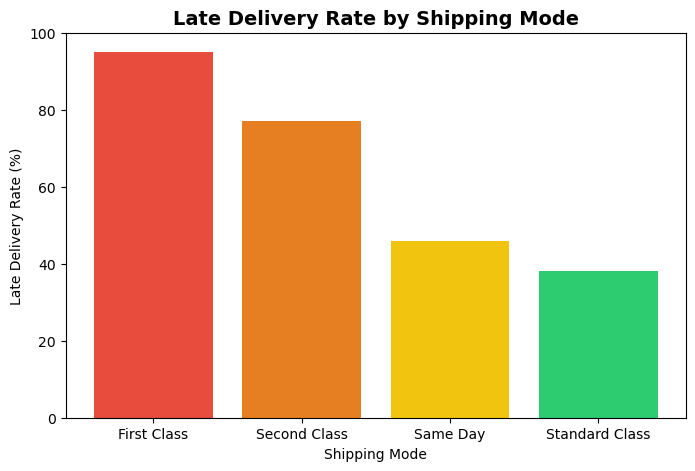

In [2]:
shipping_data = {'First Class': 95, 'Second Class': 77, 'Same Day': 46, 'Standard Class': 38}

plt.figure(figsize=(8, 5))
plt.bar(shipping_data.keys(), shipping_data.values(), 
        color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'])
plt.title('Late Delivery Rate by Shipping Mode', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Mode')
plt.ylabel('Late Delivery Rate (%)')
plt.ylim(0, 100)
plt.show()

### Finding 2: The Premium Shipping Paradox
First Class shipping shows the highest late delivery rate at 95%, 
while Standard Class — the slowest and cheapest option — performs best at only 38% late.
This suggests that premium shipping promises unrealistic delivery timelines 
that cannot be met operationally.

In [25]:
df_clean['shipping_gap'].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: shipping_gap, dtype: float64

In [26]:
df_clean.groupby('Shipping Mode')['shipping_gap'].mean().round(2)

Shipping Mode
First Class       1.00
Same Day          0.48
Second Class      1.99
Standard Class   -0.00
Name: shipping_gap, dtype: float64

In [28]:
total = df_clean.groupby('Shipping Mode')['Order Status'].count()
canceled_count = df_clean[df_clean['Order Status'] == 'CANCELED'].groupby('Shipping Mode')['Order Status'].count()
(canceled_count / total * 100).round(2)

Shipping Mode
First Class       2.21
Same Day          2.31
Second Class      1.88
Standard Class    2.03
Name: Order Status, dtype: float64

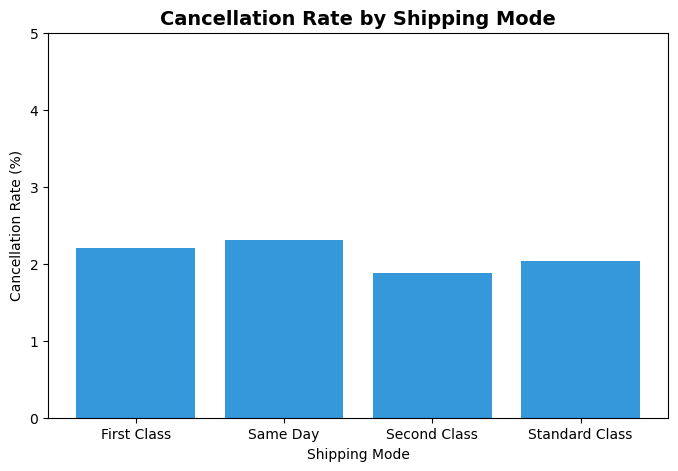

In [3]:
cancel_data = {'First Class': 2.21, 'Same Day': 2.31, 'Second Class': 1.88, 'Standard Class': 2.03}

plt.figure(figsize=(8, 5))
plt.bar(cancel_data.keys(), cancel_data.values(), color='#3498db')
plt.title('Cancellation Rate by Shipping Mode', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Mode')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 5)
plt.show()

### Finding 3: Cancellation is Not Related to Shipping Mode
Cancellation rates are nearly identical across all shipping methods (1.88% - 2.31%).
This suggests that order cancellations are driven by other factors,
not by the shipping method chosen.

## Key Findings & Recommendations

### Key Findings
1. **Systemic Failure**: 55% of all orders are delivered late — this is a process-wide issue, not regional or product-specific.
2. **Premium Shipping Paradox**: First Class has the highest late delivery rate (95%), while Standard Class performs best (38%).
3. **Cancellation is Uniform**: Order cancellation rates are consistent across all shipping modes (~2%), indicating cancellations are not shipping-related.

### Recommendations
1. **Revise delivery time promises** for First Class and Second Class shipping — current timelines are unrealistic.
2. **Investigate Standard Class operations** to understand why it outperforms premium options and replicate its practices.
3. **Investigate cancellation root causes** through customer feedback, as shipping mode alone does not explain cancellations.